# Experiment 1: O04e Focal Length and Principal Planes of a Lens System

### Yaman Ajaj (3722952) ; Guilherme Schewtschik (3748052)


## The setup:
### Task1:
For task 1 we used the lense system III that has a distance between the lenses of $d_I = 272 mm$. We did 10 mesurements by keeping the illuminated light in a fixed position ($20 mm$ without correction distance), and we moved the eye piece from starting position of $533 mm$ to $800 mm$ (without correction distance), then each measurement after that we moved it away from the lamp by $50 mm$. Each time we moved the eye piece we tried to find the position of the center of the lens system in which the image through the eye piece was the most clear. Each time we wrote down the distances between the lamp and center of the lens system, and the distance between the center of the lens system and the eye piece.
For each measurement we looked through the eye piece and we centered the cross at the bottom of one of scale lines then we read the number on the internal scale and we wrote it down. Then we moved the cross $1 mm$ down (to the bottom of the next scale line) and we read the number on the internal scale again.

### Task2: Bessel's method
- We replaced the glass scale with the P.
- We removed the two lens system and we swapped it wth the Lens 1.
- We swapped the eye piece with a screen.
We started our measurements by putting the screen at distance $1030 mm$, then we moved the lens closer to the lamp until we saw a clear image on the screen and we wrote down this distance ($D_1$), and then we moved the lens away from the lamp until we saw a clear image on the screen again and we wrote down this distance ($D_2$). We repeated this process for 3 measurements, by moving the screen away from the lamp.
We did the same process for the second lens. But this time we put the screen at distance $1975 mm$ and we moved it closer for each measurement.

## Theoretical background:
### Task1:
When working with a system of two thin lenses separated by a distance $d_l$, the system behaves like a thick lens with two principal planes (H and H') and an effective focal length $f_{sys}$.

You can’t use the simple thin lens equation directly. Instead, the imaging relations are:
$$\gamma = \frac{b'}{f_{\text{sys}}} - \frac{h'}{f_{\text{sys}}}
$$
$$\frac{1}{\gamma} = \frac{g'}{f_{\text{sys}}} - \frac{h}{f_{\text{sys}}}
$$

Where:
   - g′ is the distance from the object reference point (A) to the object.
   - b´ is the distance from A to the image.
   - h is the distance from A to the front principal plane (H).
   - h′ is the distance from A to the rear principal plane (H′).
   - $\gamma = \frac{B}{G}$ is the magnification.


These two equations are linear in form, so you can:
- Plot $\frac{1}{\gamma}$ vs g´.
- Plot $\gamma$ vs b´.

And use linear regression to extract:
- the slope = $\frac{1}{f_{\text{sys}}}$.
- the intercept = $-\frac{h}{f_{\text{sys}}}$ and $-\frac{h'}{f_{\text{sys}}}$.

Then:
- $f_{\text{sys}} = \frac{1}{\text{slope}}$.
- $h = -\text{intercept} * f_{\text{sys}}$.
- $h' = -\text{intercept} * f_{\text{sys}}$.

### Task2:
Bessel’s method relies on the lens equation:
$$\frac{1}{f} = \frac{1}{g} + \frac{1}{b}$$

Where:
- f is the focal length of the lens.
- g is the object distance (distance from the lens to the object).
- b is the image distance (distance from the lens to the image).

In the experiment:

- The total distance $s=g+bs=g+b$ (object-to-screen distance) is fixed.
- The lens is moved along this interval to find two positions where the image is sharp (i.e., a real image is formed on the screen).

Let:
$$ a = |g_1 - g_2| = |b_1 - b_2| $$

be the distance between the two sharp-image lens positions.
#### Derivation of Bessel’s Formula:
We start with the first sharp image position:
- $g=g_1$
- $b=b_1=s−g$
From the lens equation:
$$\frac{1}{f} = \frac{1}{g} + \frac{1}{s - g}
\Rightarrow
f = \left( \frac{1}{g} + \frac{1}{s - g} \right)^{-1}$$

Now simplify:
$$\frac{1}{g} + \frac{1}{s - g} = \frac{s}{g(s - g)}
\Rightarrow
f = \frac{g(s - g)}{s}$$

To express this in terms of $a$ and $s$, use the fact that the two sharp positions are symmetric around the midpoint, so:
$$g = \frac{s - a}{2}, \quad b = \frac{s + a}{2}$$

Then plug into the focal length expression:
$$f = \frac{\left( \frac{s - a}{2} \right)\left( \frac{s + a}{2} \right)}{s}
= \frac{s^2 - a^2}{4s}$$


#### Condition for Applicability:

To ensure two real solutions, we must have:$$s>4f$$

This ensures that the lens equation has two real, distinct solutions for sharp image positions.

## Analysis:

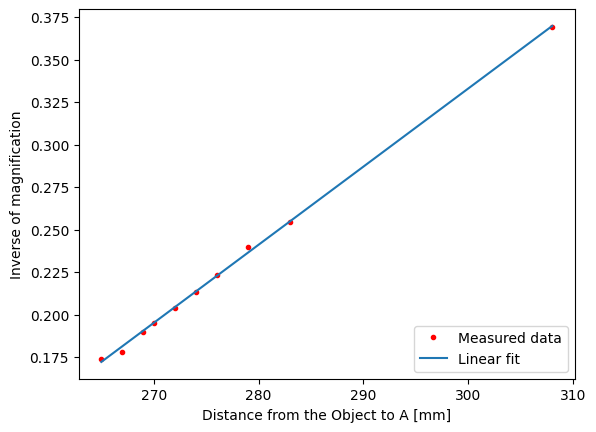

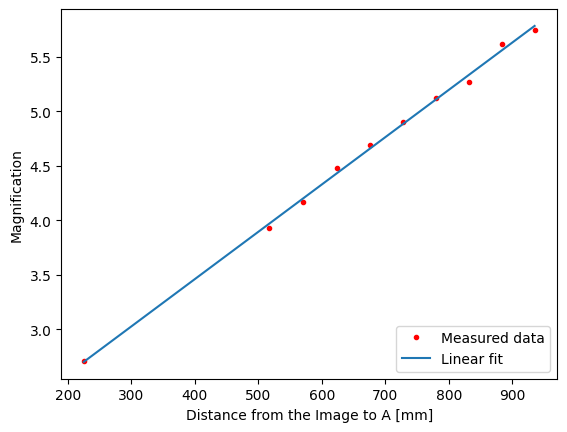

Effective focal length (F_sys): 223.81609266920069
h: 234.04203236652774
h': -386.21648026221806


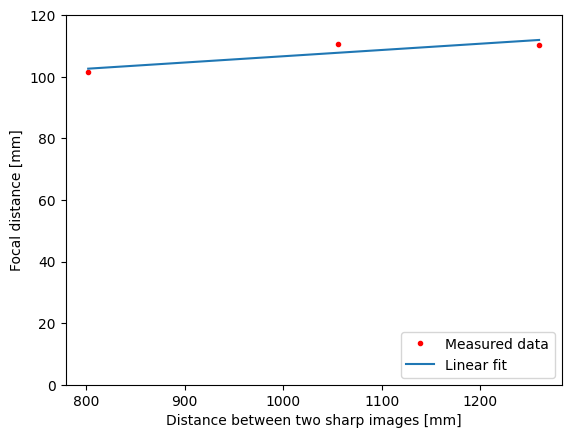

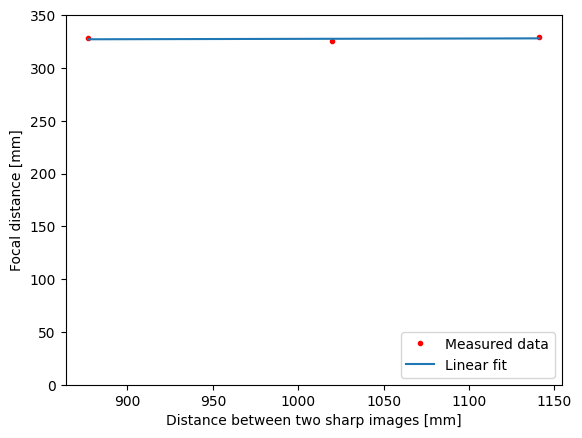

Screen positions for Lens 2: [1975 1862 1751]
Focal lengths for Lens 2 (scaled): [1315.819746835443 1303.2459720730396 1311.7487150199886]


In [13]:
#Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Data import and adjusting
data1_pd = pd.read_excel('Data.xlsx', sheet_name=0)
data1 = data1_pd.to_numpy()

data2_pd = pd.read_excel('Data.xlsx', sheet_name=1, header=1)
data2 = data2_pd.to_numpy()

# Task 1

# Getting the relevant values from the data
g_1 = data1[:, 7]
b_1 = data1[:, 9]
gamma = data1[:, 6]
gamma_inv = 1 / gamma

# Plot of 1/gamma vs g'
gT = g_1.reshape((-1, 1))

# Fitting
model1 = LinearRegression().fit(gT, gamma_inv)

A1 = model1.coef_
B1 = model1.intercept_

# Plotting
plt.figure(1)
plt.xlabel('Distance from the Object to A [mm]')
plt.ylabel('Inverse of magnification')
plt.plot(gT, gamma_inv, '.', color='red', label='Measured data')
plt.plot(gT, model1.predict(gT), label='Linear fit')
plt.legend(loc='lower right')
plt.savefig('g_vs_1_mag.png')
plt.show()

# Plot of gamma vs b'
bT = b_1.reshape((-1, 1))

# Fitting
model2 = LinearRegression().fit(bT, gamma)

A2 = model2.coef_
B2 = model2.intercept_

# Plotting
plt.figure(2)
plt.xlabel('Distance from the Image to A [mm]')
plt.ylabel('Magnification')
plt.plot(bT, gamma, '.', color='red', label='Measured data')
plt.plot(bT, model2.predict(bT), label='Linear fit')
plt.legend(loc='lower right')
plt.savefig('b_vs_mag.png')
plt.show()

# Calculations
A_mean = (A1 + A2) / 2
F_sys = 1 / A_mean
h = -B1 * F_sys
h_p = -B2 * F_sys

print("Effective focal length (F_sys):", F_sys[0])
print("h:", h[0])
print("h':", h_p[0])

# Task 2

# Data
screen_pos_l1 = data2[:, 1]
pos_l1_1 = data2[:, 2]
pos_l1_2 = data2[:, 3]

screen_pos_l2 = data2[:, 6]
pos_l2_1 = data2[:, 7]
pos_l2_2 = data2[:, 8]

# Calculations
a_l1 = pos_l1_2 - pos_l1_1
a_l2 = pos_l2_2 - pos_l2_1

f_l1 = (screen_pos_l1 * screen_pos_l1 - a_l1 * a_l1) / (4 * screen_pos_l1)
f_l2 = (screen_pos_l2 * screen_pos_l2 - a_l2 * a_l2) / (4 * screen_pos_l2)

# Fitting
a_l1T = a_l1.reshape((-1, 1))
model3 = LinearRegression().fit(a_l1T, f_l1)

a_l2T = a_l2.reshape((-1, 1))
model4 = LinearRegression().fit(a_l2T, f_l2)

# Plotting for Lens 1
plt.figure(3)
plt.ylabel('Focal distance [mm]')
plt.xlabel('Distance between two sharp images [mm]')
plt.ylim([0, 120])
plt.plot(a_l1, f_l1, '.', color='red', label='Measured data')
plt.plot(a_l1, model3.predict(a_l1T), label='Linear fit')
plt.legend(loc='lower right')
plt.savefig('focal_length_1.png')
plt.show()

# Plotting for Lens 2
plt.figure(4)
plt.ylabel('Focal distance [mm]')
plt.xlabel('Distance between two sharp images [mm]')
plt.ylim([0, 350])
plt.plot(a_l2, f_l2, '.', color='red', label='Measured data')
plt.plot(a_l2, model4.predict(a_l2T), label='Linear fit')
plt.legend(loc='lower right')
plt.savefig('focal_length_2.png')
plt.show()

print("Screen positions for Lens 2:", screen_pos_l2)
print("Focal lengths for Lens 2 (scaled):", f_l2 * 4)

In [19]:
# h' and h are already calculated
H_1 = h + F_sys  # Front principal plane
H_2 = h_p - F_sys  # Rear principal plane
gamma_task1 = A_mean  # Magnification from Task 1

print("Task 1 Results:")
print("h':", h_p[0])
print("h:", h[0])
print("H_1 (Front Principal Plane):", H_1[0])
print("H_2 (Rear Principal Plane):", H_2[0])
print("Gamma (Magnification):", gamma_task1[0])
print("Effective Focal Length (f_sys):", F_sys[0])

f_1 = np.mean(f_l1)  # Average focal length for Lens 1
f_2 = np.mean(f_l2)  # Average focal length for Lens 2
f_sys_task2 = 1 / (1 / f_1 + 1 / f_2 - (272 / (f_1 * f_2)))  # Effective focal length for the system

print("\nTask 2 Results:")
print("Focal Length of Lens 1 (f_1):", f_1)
print("Focal Length of Lens 2 (f_2):", f_2)
print("Effective Focal Length (f_sys):", f_sys_task2)

print("\nComparison of Results:", g_1)
print("Effective Focal Length (f_sys): Task 1 =", F_sys[0], ", Task 2 =", f_sys_task2)
print("Magnification (gamma): Task 1 =", gamma_task1)
print(f"Principal Planes (H_1, H_2): Task 1 = {H_1[0]} , {H_2[0]}")

Task 1 Results:
h': -386.21648026221806
h: 234.04203236652774
H_1 (Front Principal Plane): 457.85812503572845
H_2 (Rear Principal Plane): -610.0325729314187
Gamma (Magnification): 0.004467953970932716
Effective Focal Length (f_sys): 223.81609266920069

Task 2 Results:
Focal Length of Lens 1 (f_1): 107.44443116753796
Focal Length of Lens 2 (f_2): 327.56786949403926
Effective Focal Length (f_sys): 215.9060590134047

Comparison of Results: [308 283 279 276 274 272 270 269 267 265]
Effective Focal Length (f_sys): Task 1 = 223.81609266920069 , Task 2 = 215.9060590134047
Magnification (gamma): Task 1 = [0.00446795]
Principal Planes (H_1, H_2): Task 1 = 457.85812503572845 , -610.0325729314187
